# Tilt Observer Results

This notebook discovers CSV files written by `evalTiltObserver`, loads the latest run by default, unwraps angle branches per dataset, and renders roll/pitch and gyroscope-bias estimates for every dataset.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_rows = 20

# Set RUN_DIR to a specific evalTiltObserver run directory to pin a run.
RUN_DIR = None

notebook_dir = Path.cwd()
candidate_roots = [
    notebook_dir / "../build/results/evalTiltObserver",
    notebook_dir / "../results/evalTiltObserver",
    notebook_dir / "build/results/evalTiltObserver",
    notebook_dir / "results/evalTiltObserver",
]

if RUN_DIR is None:
    run_dirs = sorted({path.parent for root in candidate_roots for path in root.glob("*/tilt_observer_*.csv")})
    if not run_dirs:
        raise FileNotFoundError("No tilt observer CSV files found. Run ./evalTiltObserver from the build directory first.")
    run_dir = run_dirs[-1]
else:
    run_dir = Path(RUN_DIR).expanduser().resolve()

csv_files = sorted(run_dir.glob("tilt_observer_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No tilt observer CSV files found in {run_dir}")

frames = [pd.read_csv(path) for path in csv_files]
data = pd.concat(frames, ignore_index=True)
data = data.sort_values(["dataset", "sample_index"]).reset_index(drop=True)

angle_columns = ["gt_roll_rad", "gt_pitch_rad", "est_roll_rad", "est_pitch_rad"]
for column in angle_columns:
    unwrapped = data.groupby("dataset")[column].transform(lambda values: np.unwrap(values.to_numpy()))
    data[column.replace("_rad", "_unwrapped_rad")] = unwrapped
    data[column.replace("_rad", "_deg")] = np.degrees(unwrapped)

print(f"Loaded {len(csv_files)} CSV files from {run_dir}")
display(data.groupby("dataset").agg(samples=("sample_index", "count"), duration_s=("timestamp", "max")))

Loaded 11 CSV files from /Users/dellaert/git/imuFactors/notebooks/../build/results/evalTiltObserver/20260505T011349034Z


,samples,duration_s
dataset,,
MH01,28826,144.125
MH02,22728,113.635
MH03,22887,114.430
MH04,15980,79.895
MH05,18580,92.895
V101,27871,139.350
V102,16009,80.040
V103,20350,101.745
V201,21032,105.155


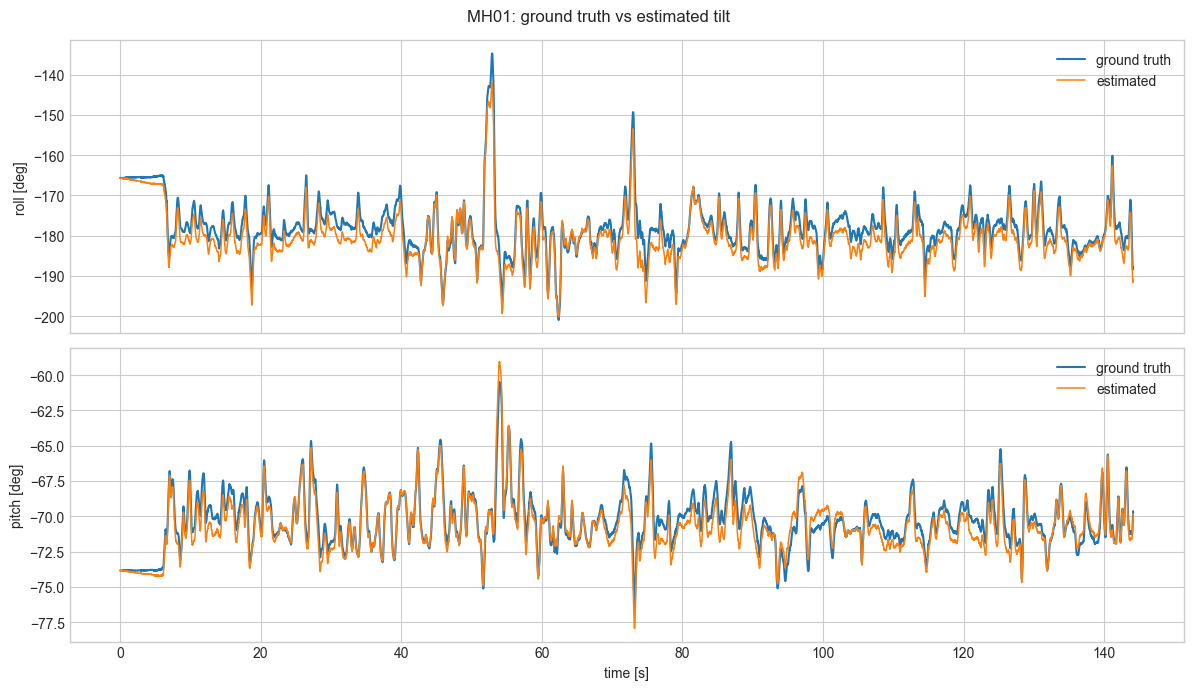

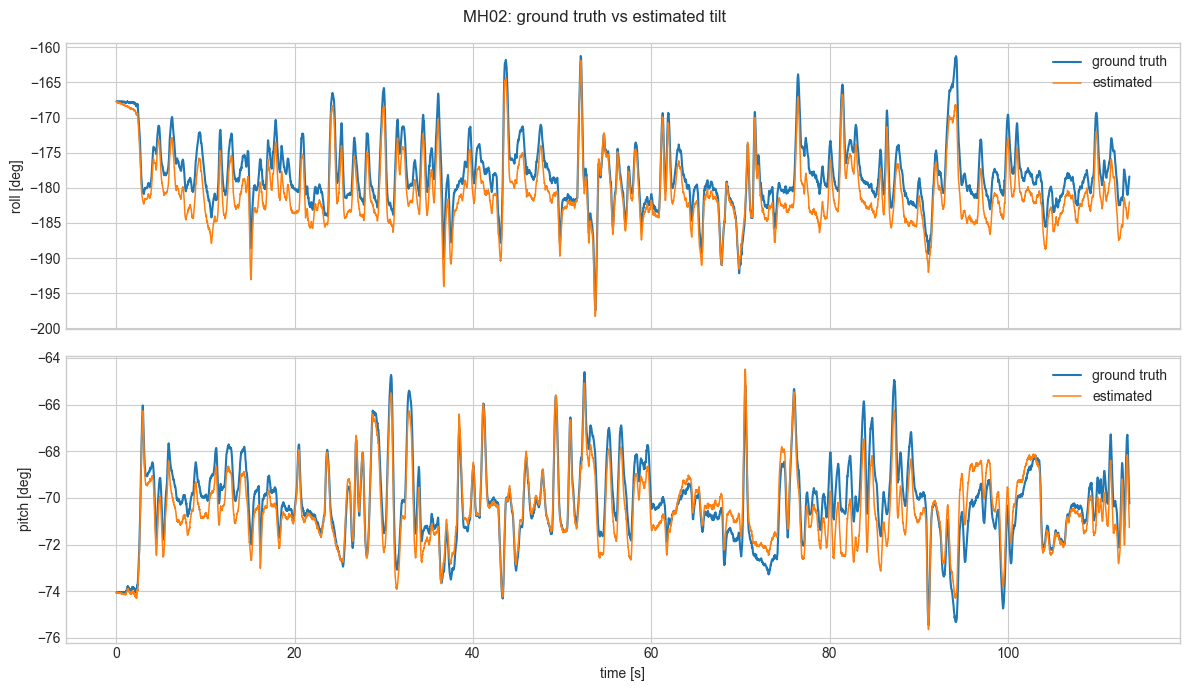

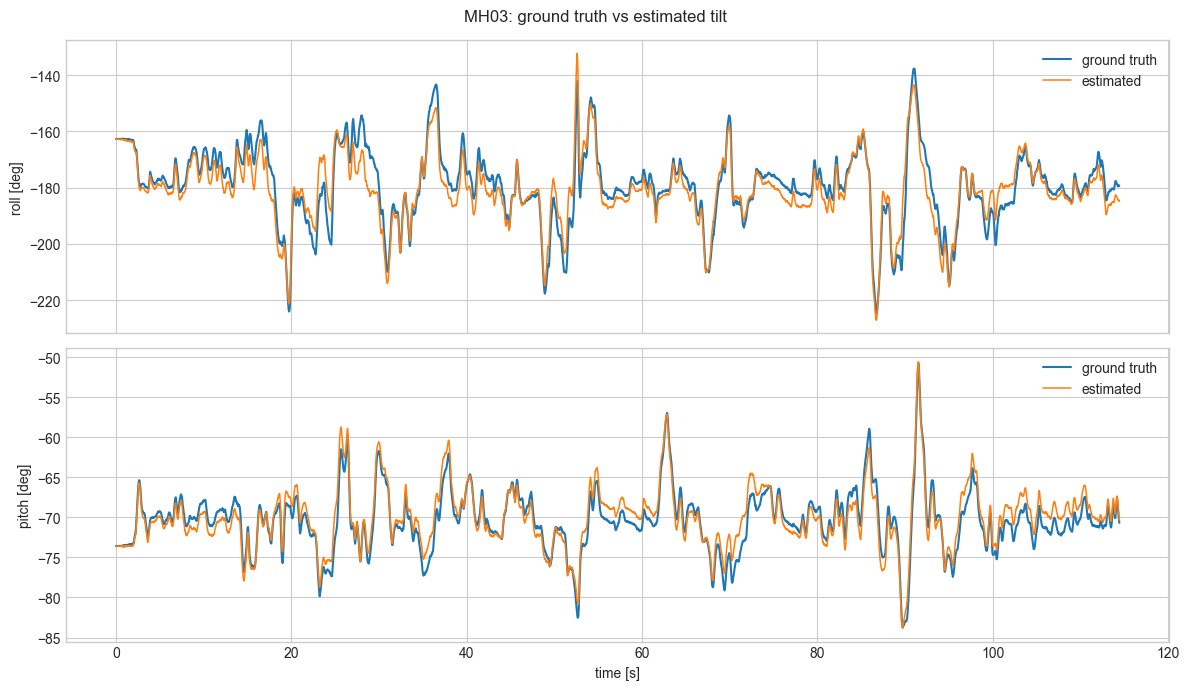

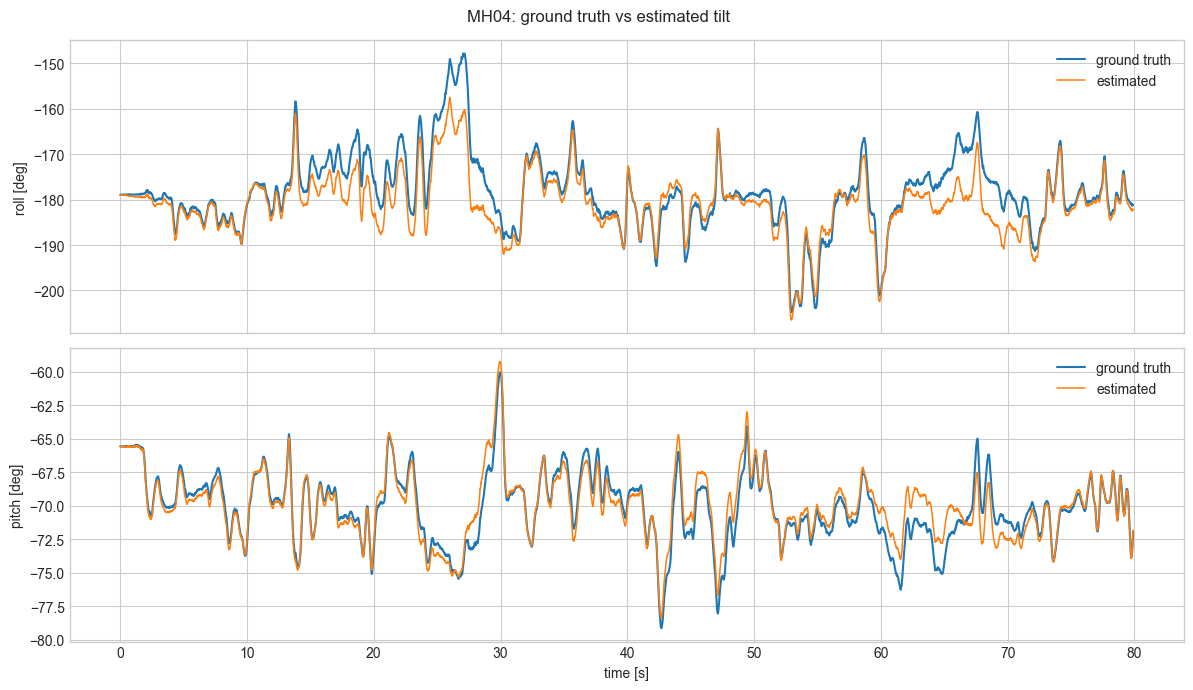

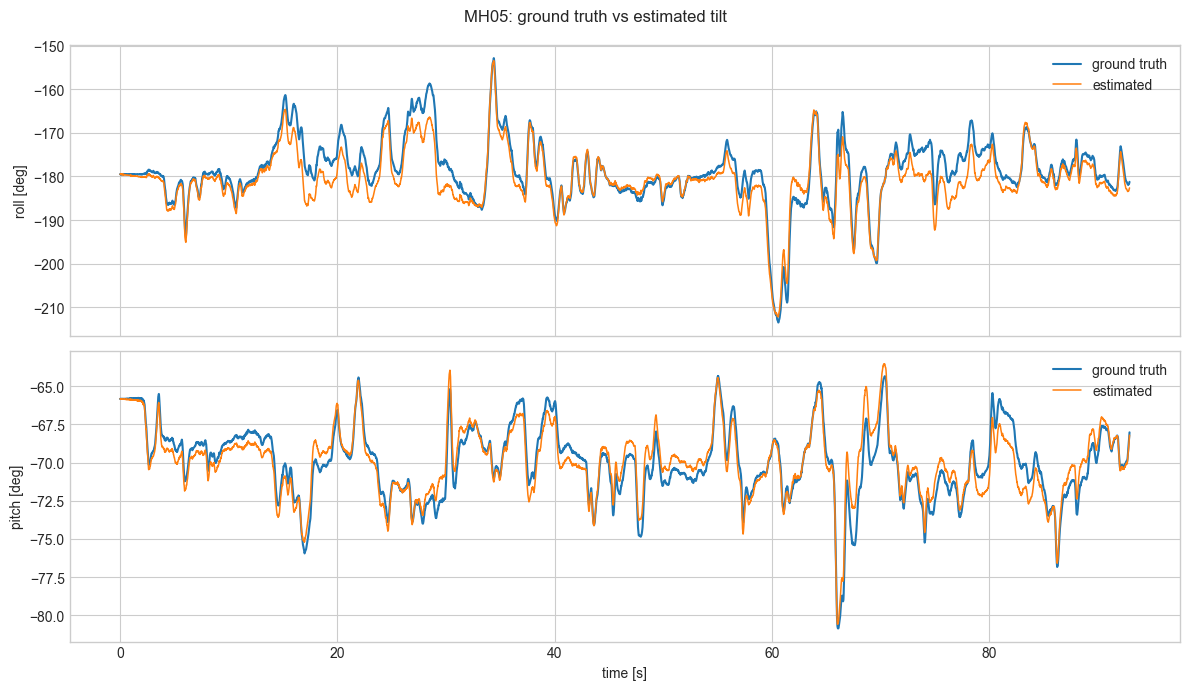

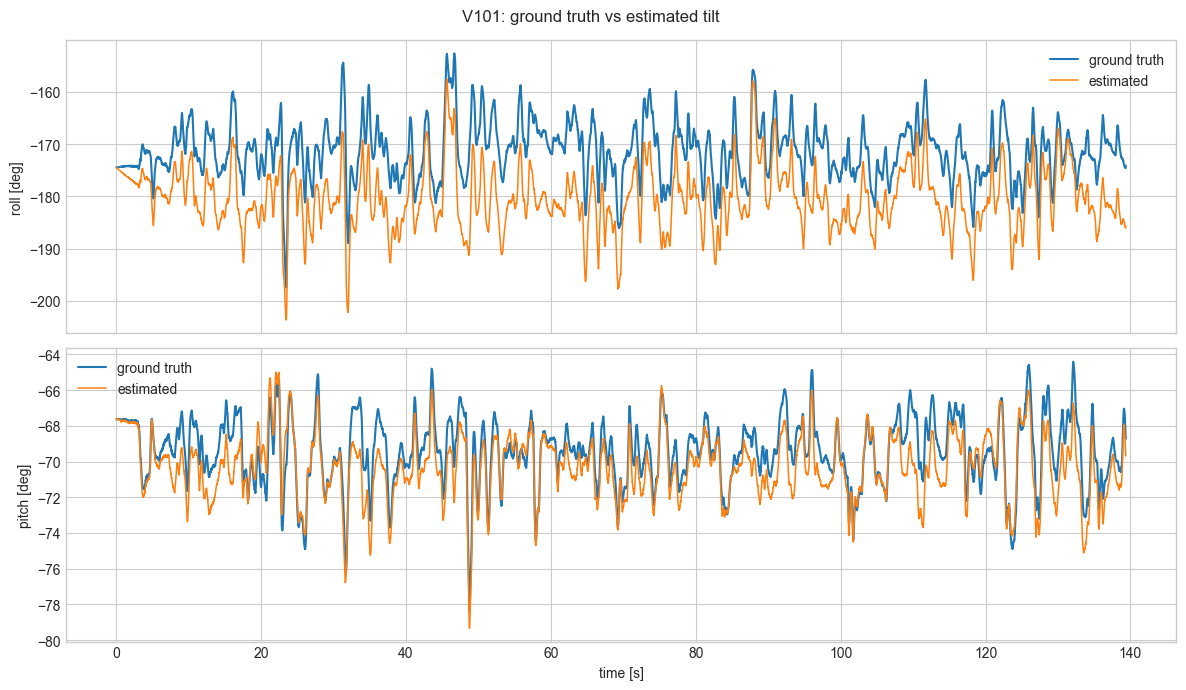

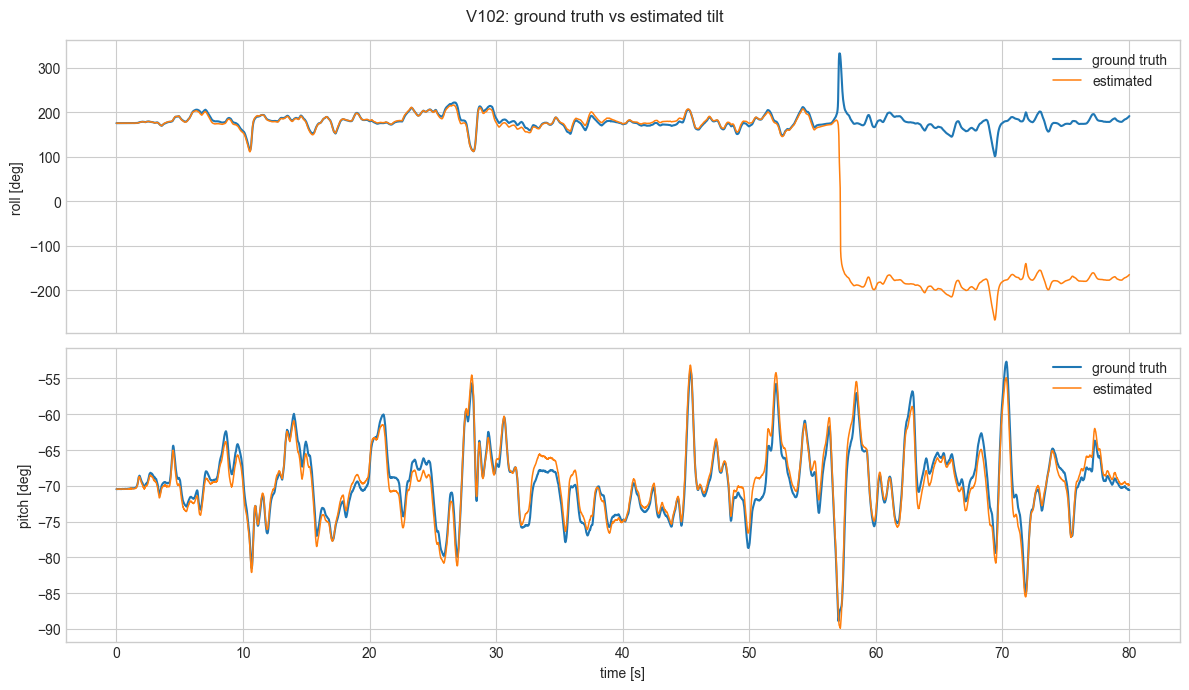

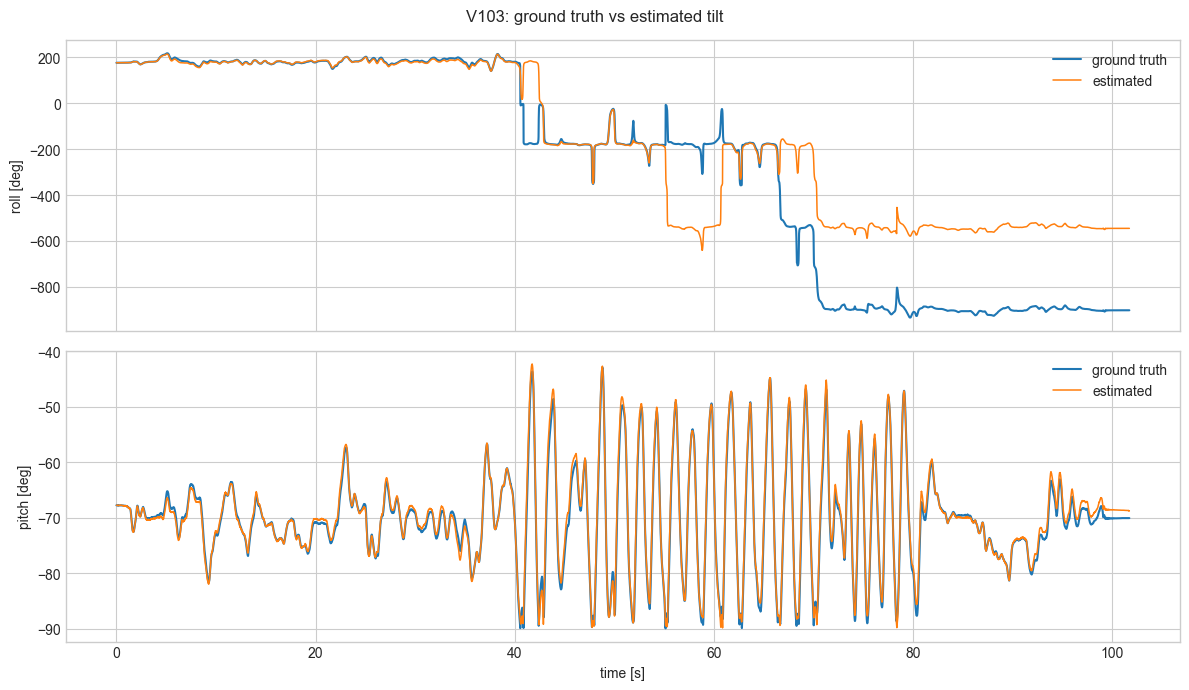

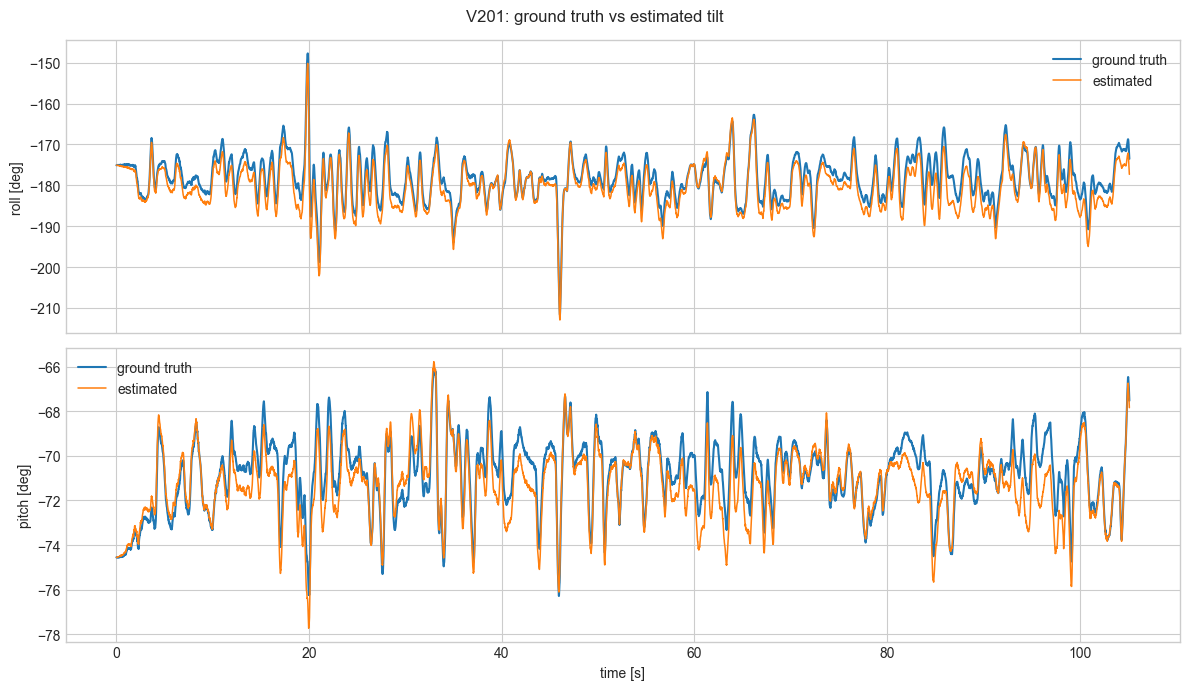

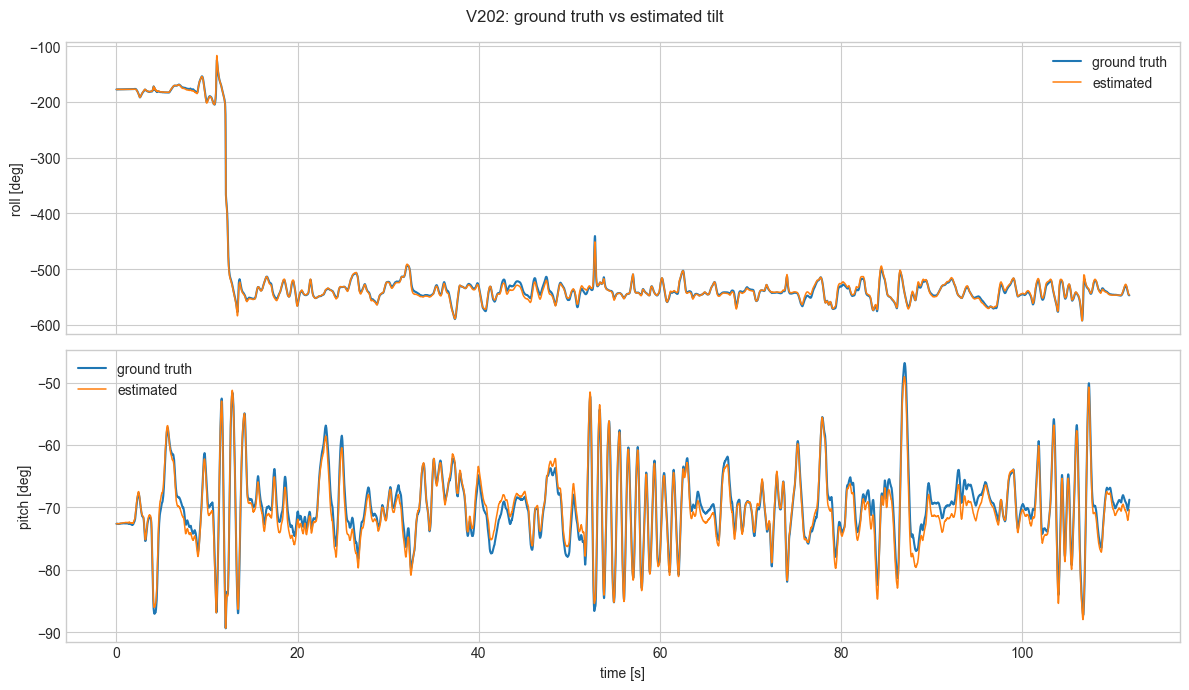

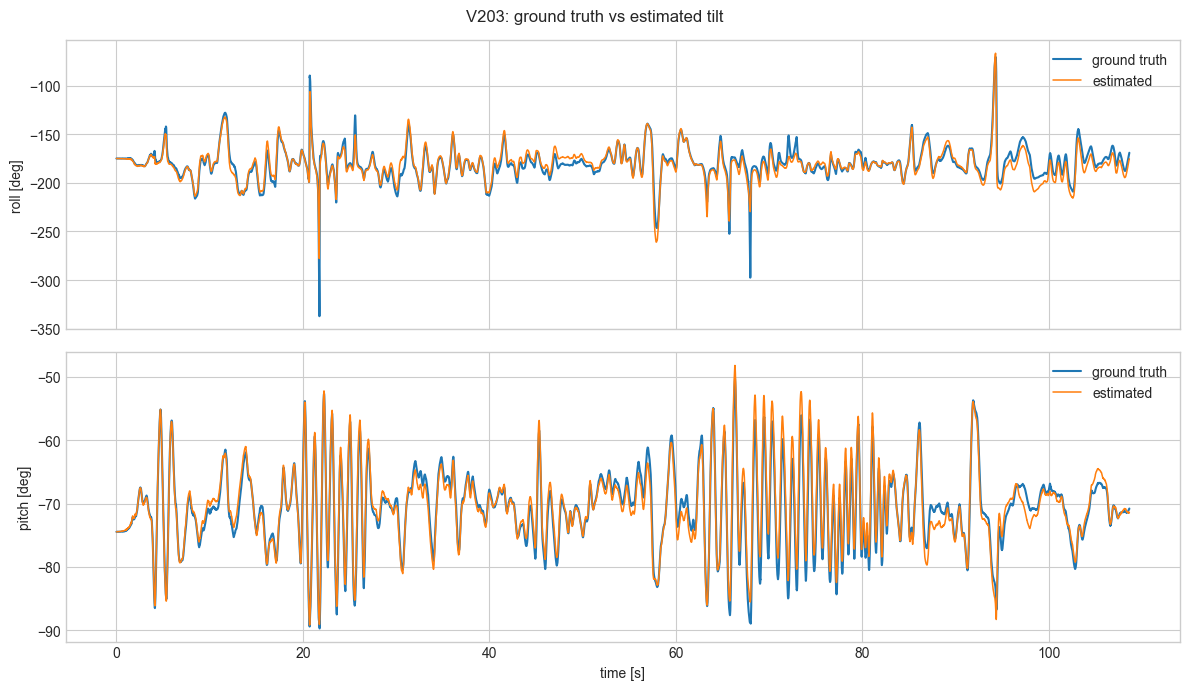

In [20]:
for dataset, df in data.groupby("dataset", sort=True):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"{dataset}: ground truth vs estimated tilt")

    axes[0].plot(df["timestamp"], df["gt_roll_deg"], label="ground truth")
    axes[0].plot(df["timestamp"], df["est_roll_deg"], label="estimated", linewidth=1.1)
    axes[0].set_ylabel("roll [deg]")
    axes[0].legend(loc="best")

    axes[1].plot(df["timestamp"], df["gt_pitch_deg"], label="ground truth")
    axes[1].plot(df["timestamp"], df["est_pitch_deg"], label="estimated", linewidth=1.1)
    axes[1].set_ylabel("pitch [deg]")
    axes[1].set_xlabel("time [s]")
    axes[1].legend(loc="best")

    fig.tight_layout()
    plt.show()

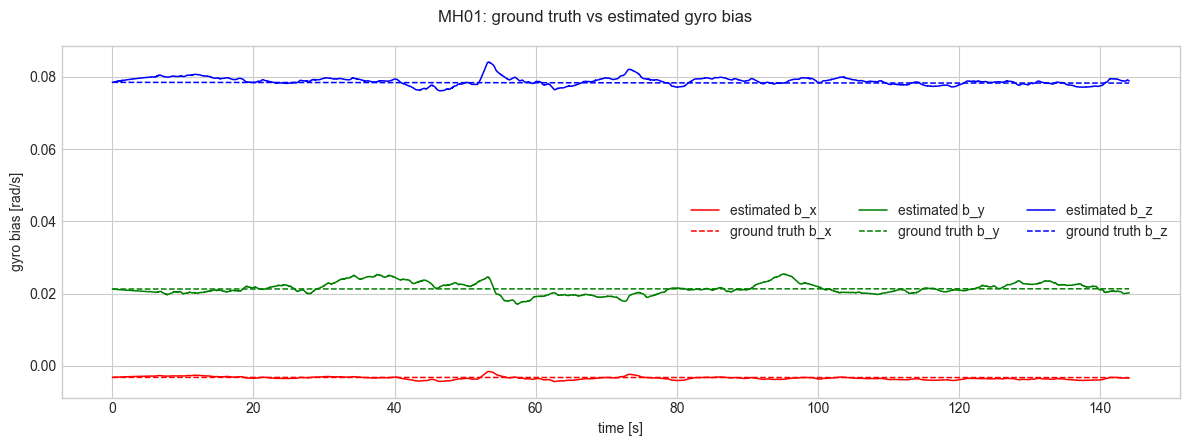

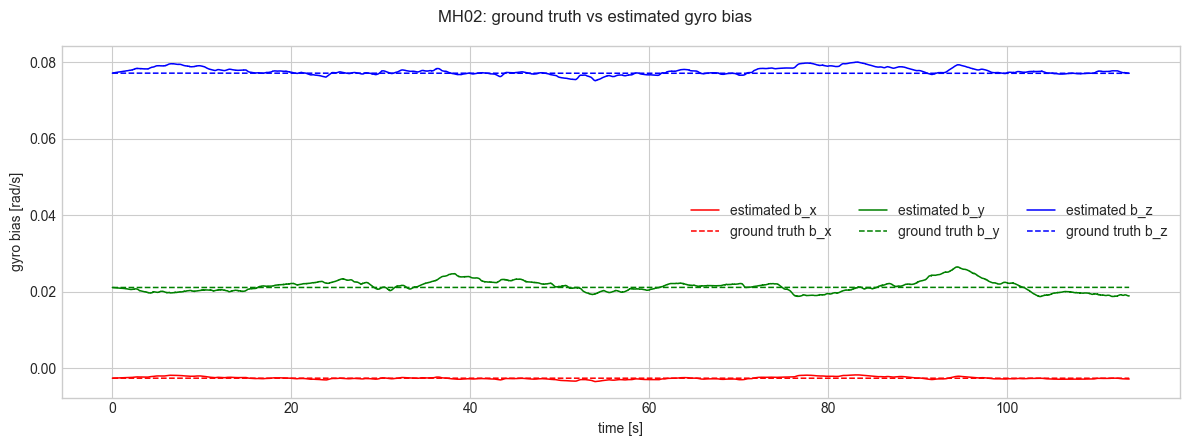

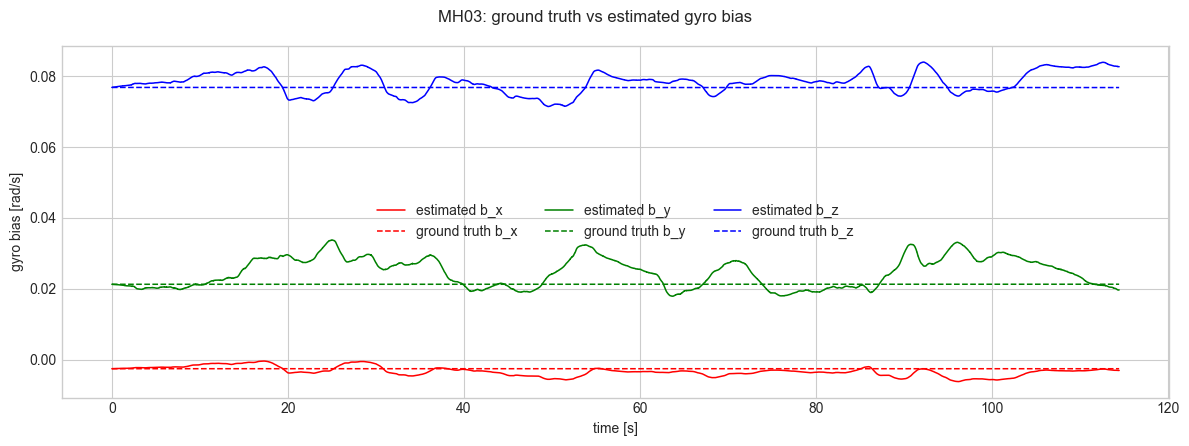

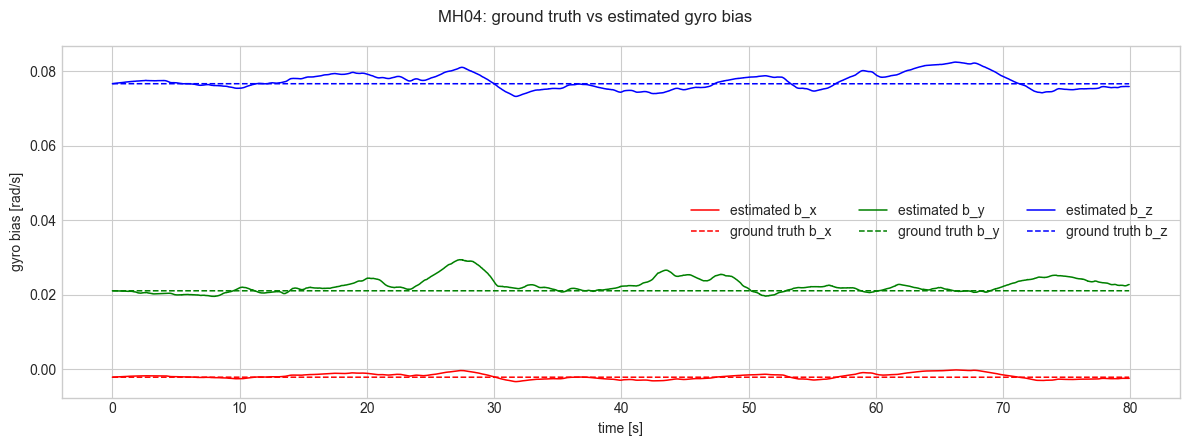

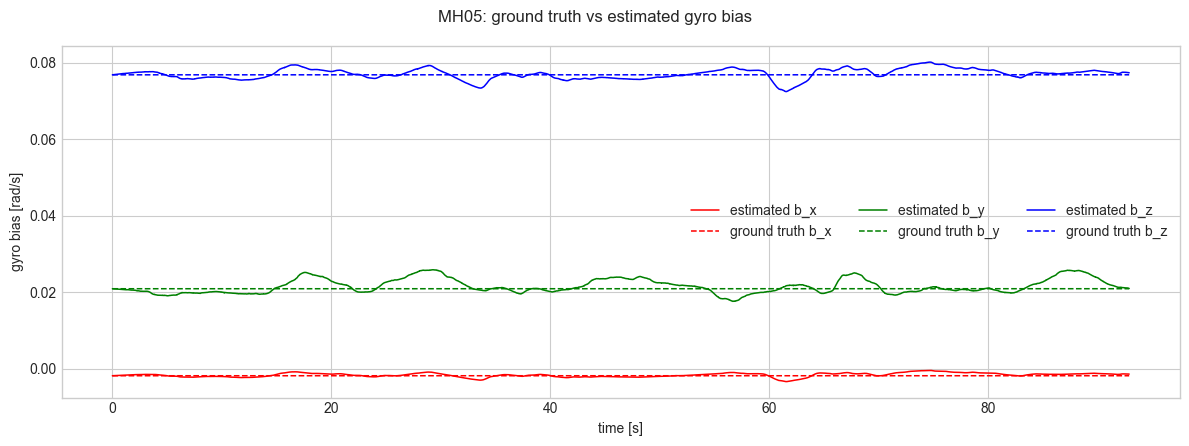

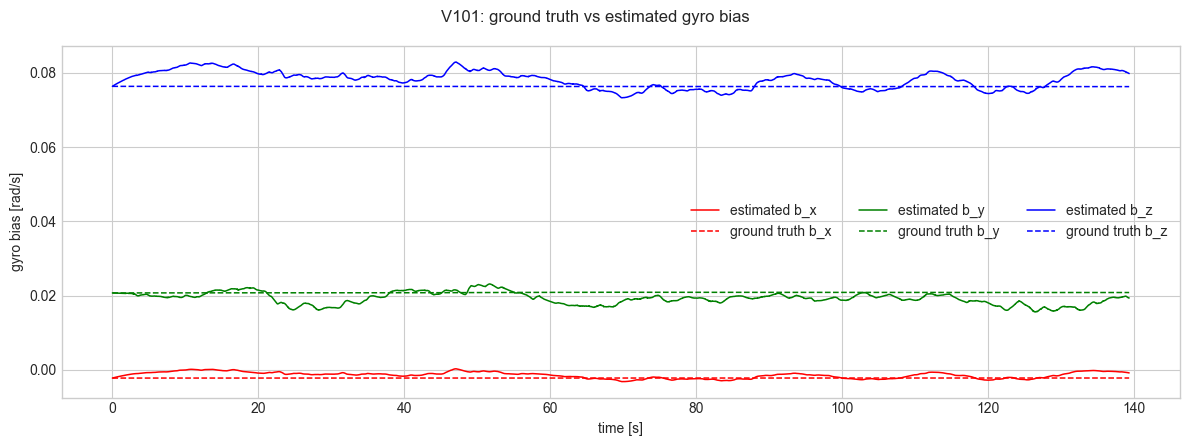

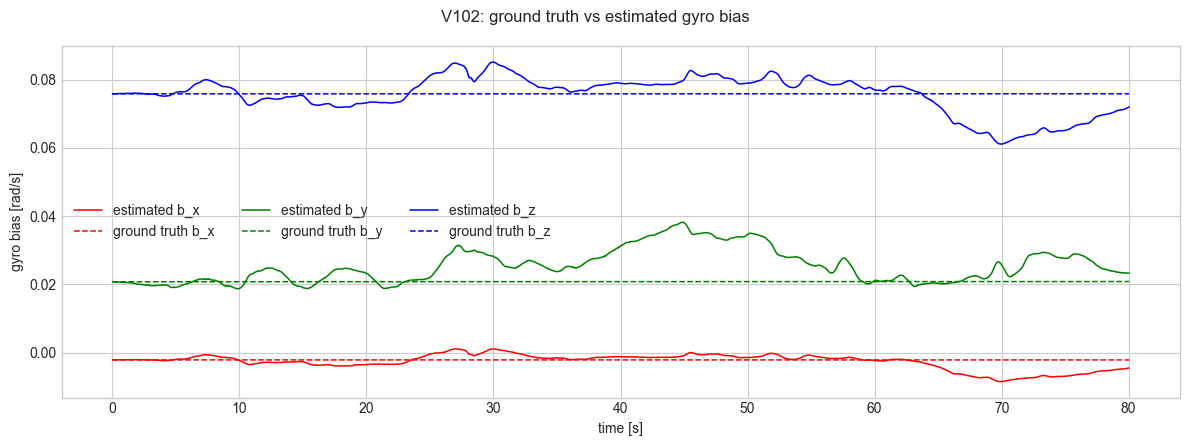

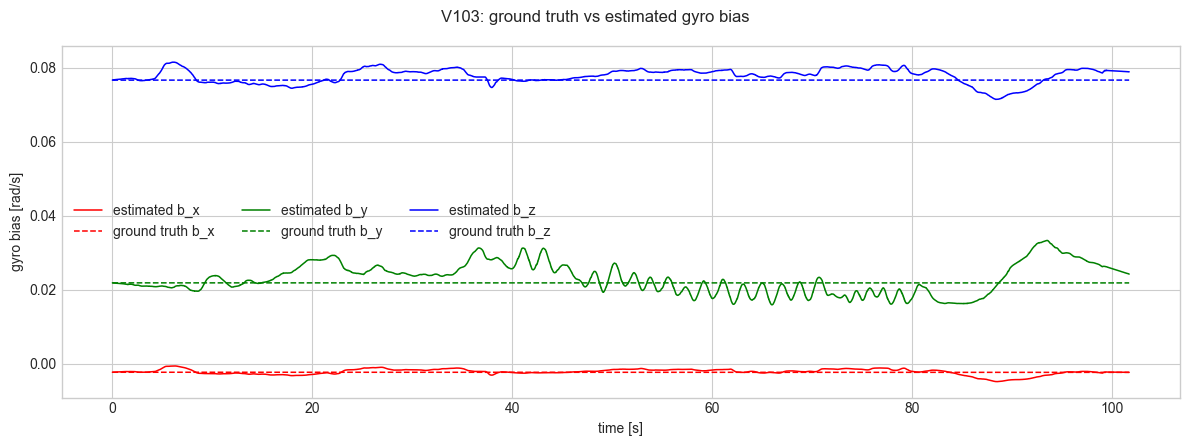

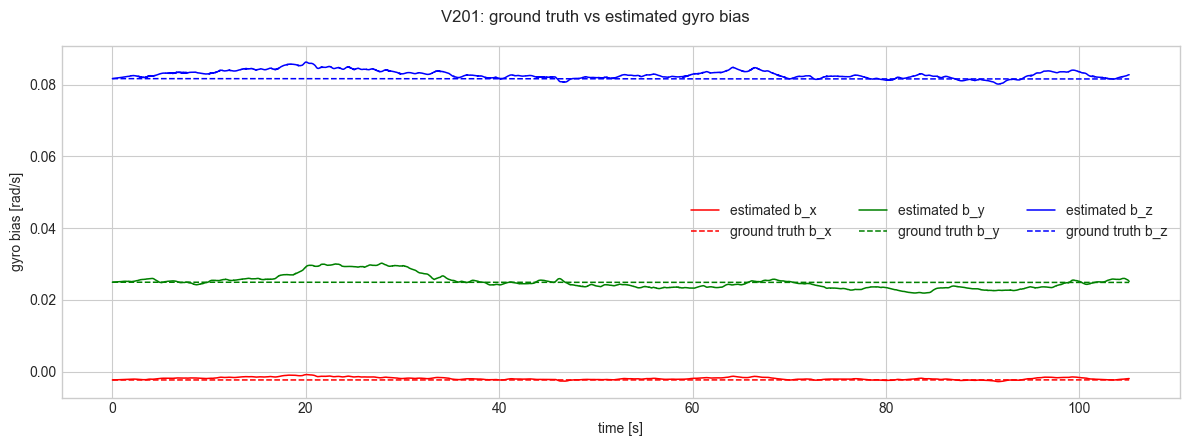

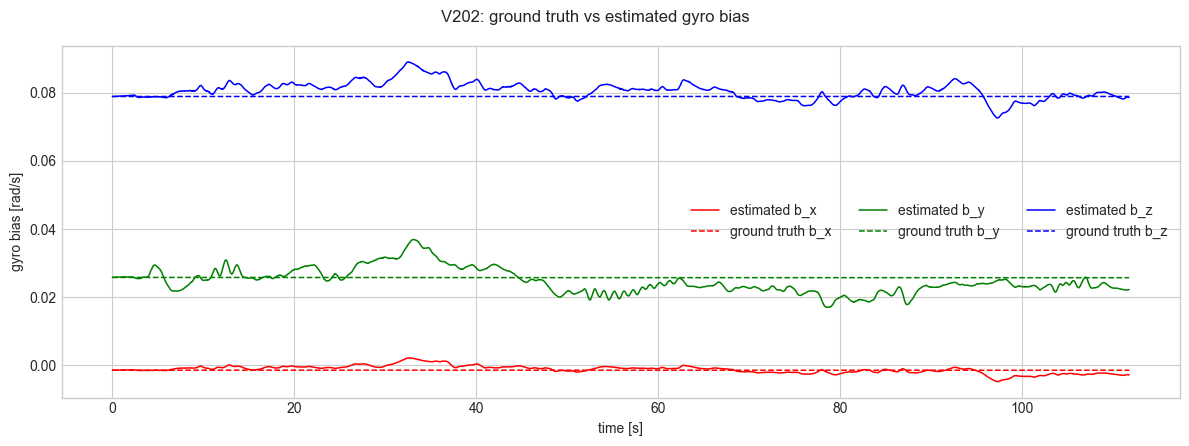

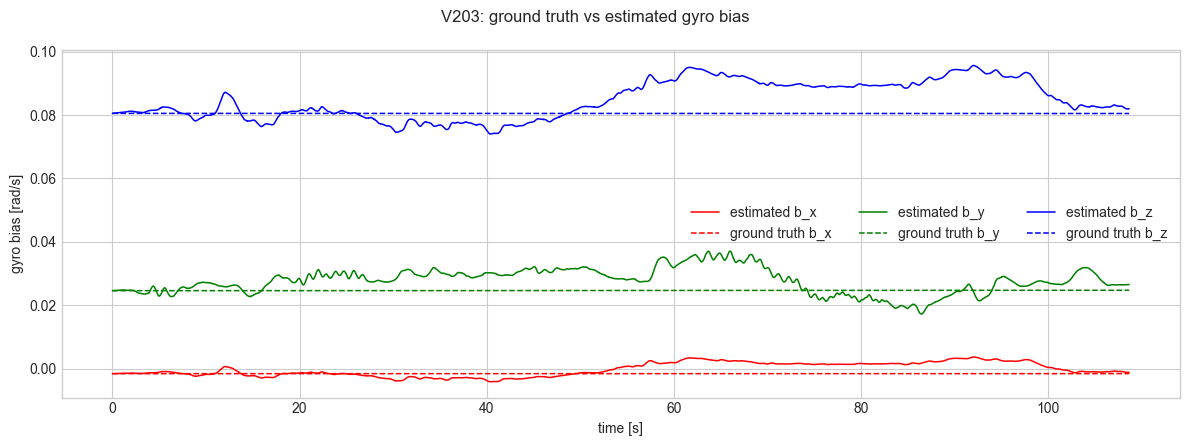

In [21]:
bias_axes = [
    ("x", "red"),
    ("y", "green"),
    ("z", "blue"),
]
for dataset, df in data.groupby("dataset", sort=True):
    fig, axis = plt.subplots(1, 1, figsize=(12, 4.5), sharex=True)
    fig.suptitle(f"{dataset}: ground truth vs estimated gyro bias")

    for component, color in bias_axes:
        axis.plot(
            df["timestamp"],
            df[f"est_gyro_bias_{component}"],
            color=color,
            linewidth=1.1,
            label=f"estimated b_{component}",
        )
        axis.plot(
            df["timestamp"],
            df[f"gt_gyro_bias_{component}"],
            color=color,
            linestyle="--",
            linewidth=1.1,
            label=f"ground truth b_{component}",
        )

    axis.set_ylabel("gyro bias [rad/s]")
    axis.set_xlabel("time [s]")
    axis.legend(loc="best", ncol=3)
    fig.tight_layout()
    plt.show()
